## La chiave: i dati

I **dati** sono la chiave per risolvere problemi utilizzando il machine learning. 
Molto spesso i dati utili ad un certo problema sono già stati raccolti da qualcun altro, e noi dobbiamo solo imparare a usarli. In questo caso, si tratta di **dataset pubblico** [FIFA Players Dataset](https://www.kaggle.com/datasets/luisfucros/fifa-players) distribuito su una delle piattaforme più popolari per la condivisione di dati, [**Kaggle**](https://www.kaggle.com/). Il dataset contiene informazioni su migliaia di calciatori, tra cui caratteristiche come età, overall, potential, e il loro valore di mercato. Benchè raccolti per il videogioco FIFA, questi dati sono fedeli alla realtà del calcio professionistico.

Per rendere il codice stabile, non scarichiamo direttamente da Kaggle durante la lezione: usiamo una copia congelata in uno ZIP Dropbox preparato per il corso.

[![Apri in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/riccardoberta/regressione/blob/main/01_il_mistero_del_valore.ipynb)

# Il mistero del valore di mercato

*Siamo il reparto dati di una società sportiva. Il direttore sportivo ci chiede di capire perché alcuni calciatori valgono pochi milioni e altri cifre enormi.*

**Cosa ci serve sapere?**

*Il direttore sportivo ci consegna un file enorme: i dati di tutti i calciatori professionisti* 

In [3]:
# Librerie necessarie per scaricare ed estrarre il dataset
import urllib.request, zipfile
from pathlib import Path

# Librerie per l'analisi dei dati e la visualizzazione
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Link al dataset e percorsi locali
DATA_URL = (
    "https://www.dropbox.com/scl/fi/0l5n46qjwcd5moj3w7d8p/"
    "fifa.zip?rlkey=rcqhagvq5ttlvna5t5r3vn1bm&st=uzplzs5o&dl=1"
)
ZIP_PATH = Path("fifa.zip")
DATA_DIR = Path("fifa_data")

# Scarichiamo il dataset se non è già presente
if not ZIP_PATH.exists():
    print("Scarico il dataset...")
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)

# Estraiamo il dataset se non è già stato fatto
if not list(DATA_DIR.rglob("*.csv")):
    DATA_DIR.mkdir(exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)

# Apriamo il file principale del dataset
csv_files = (
    list(DATA_DIR.rglob("players_22.csv"))
    or list(DATA_DIR.rglob("*players*.csv"))
)

# Leggiamo il file CSV usando la libreria pandas (che permette di gestire 
# facilmente i dati in tabelle)
raw_data = pd.read_csv(csv_files[0], low_memory=False)
print(f"Caricato: {raw_data.shape[0]} giocatori, {raw_data.shape[1]} colonne")

# Visualizziamo le prime righe del dataset per capire com'è strutturato
raw_data.head()

Caricato: 19239 giocatori, 110 colonne


,sofifa_id,player_url,short_name,long_name,player_positions,overall,potential,value_eur,wage_eur,age,...,lcb,cb,rcb,rb,gk,player_face_url,club_logo_url,club_flag_url,nation_logo_url,nation_flag_url
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,"RW, ST, CF",93,93,78000000.0,320000.0,34,...,50+3,50+3,50+3,61+3,19+3,https://cdn.sofifa.net/players/158/023/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,https://cdn.sofifa.net/teams/1369/60.png,https://cdn.sofifa.net/flags/ar.png
1,188545,https://sofifa.com/player/188545/robert-lewand...,R. Lewandowski,Robert Lewandowski,ST,92,92,119500000.0,270000.0,32,...,60+3,60+3,60+3,61+3,19+3,https://cdn.sofifa.net/players/188/545/22_120.png,https://cdn.sofifa.net/teams/21/60.png,https://cdn.sofifa.net/flags/de.png,https://cdn.sofifa.net/teams/1353/60.png,https://cdn.sofifa.net/flags/pl.png
2,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,"ST, LW",91,91,45000000.0,270000.0,36,...,53+3,53+3,53+3,60+3,20+3,https://cdn.sofifa.net/players/020/801/22_120.png,https://cdn.sofifa.net/teams/11/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1354/60.png,https://cdn.sofifa.net/flags/pt.png
3,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Júnior,"LW, CAM",91,91,129000000.0,270000.0,29,...,50+3,50+3,50+3,62+3,20+3,https://cdn.sofifa.net/players/190/871/22_120.png,https://cdn.sofifa.net/teams/73/60.png,https://cdn.sofifa.net/flags/fr.png,NaN,https://cdn.sofifa.net/flags/br.png
4,192985,https://sofifa.com/player/192985/kevin-de-bruy...,K. De Bruyne,Kevin De Bruyne,"CM, CAM",91,91,125500000.0,350000.0,30,...,69+3,69+3,69+3,75+3,21+3,https://cdn.sofifa.net/players/192/985/22_120.png,https://cdn.sofifa.net/teams/10/60.png,https://cdn.sofifa.net/flags/gb-eng.png,https://cdn.sofifa.net/teams/1325/60.png,https://cdn.sofifa.net/flags/be.png


Ogni riga rappresenta un calciatore. Le colonne sono caratteristiche osservabili: età, salario, club, valore economico, ecc. Nel nostro problema  il valore economico è la variabile da prevedere (**target**), mentre le altre colonne sono gli indizi (**features**) a nostra disposizione. 

Il file completo ha oltre 100 variabili, molte molto tecniche e ridondanti. Nel dettablio, possiamo raggruppare le variabili in 9 categorie:

**1. Identità e informazioni base**: informazioni che descrivono chi è il giocatore, servono per identificare e contestualizzare, non sono direttamente utili al nostro scopo di previsione.

- short_name, long_name → nome
- age → età
- nationality_name → nazionalità
- club_name → squadra
- league_name → campionato

**2. Posizione e ruolo**: descrivono dove gioca il calciatore. Pssono essere  importanti perché il valore di un giocatore può dipendere anche dal suo ruolo (un attaccante e un difensore non sono comparabili direttamente).

- player_positions → ruoli principali (es. ST, CM, CB)
- team_position → ruolo nella squadra
- preferred_foot → piede preferito

**3. Valutazioni globali** Queste sono le variabili più importanti. Sono informazioni che riassumono molte altre e possono essere considerate importanti indicatori della qualità del giocatore.

- overall → livello attuale
- potential → livello massimo raggiungibile

**4. Aspetti economici** Queste descrivono il lato “mercato” e comprendono quello che stiamo cercando di prevedere, ma anche altre variabili correlate.

- value_eur → valore di mercato (target del nostro modello)
- wage_eur → stipendio settimanale
- release_clause_eur → clausola rescissoria

**5. Statistiche tecniche**: qui entra il cuore del modello FIFA, si tratta abilità numeriche da 0 a 99 in varie aree del gioco. Sono molto interessanti, ma spesso sono correlate tra loro e con l’overall, quindi vanno usate con attenzione.

- Attacco (finishing, shot_power, positioning)
- Passaggio (short_passing, long_passing, vision)
- Dribbling (dribbling, ball_control, agility)
- Difesa (defending, standing_tackle, interceptions)
- Fisico (strength, stamina, sprint_speed)
- Caratteristiche qualitative (skill_moves, weak_foot, work_rate)

**7. Informazioni sul contratto**: le informazioni sul contratto possono influenzare il valore di mercato, ma spesso possono essere ignorate nei modelli base perché sono più difficili da interpretare e utilizzare.

- contract_valid_until
- joined
- loaned_from

**8. Dati fisici**: utili in alcuni casi, ma meno rilevanti per il valore rispetto all’overall.

- height_cm
- weight_kg

**9. Valutazioni specifiche per ruolo**: si tratta di aggregazioni delle statistiche tecniche.

- pace, shooting, passing, dribbling, defending, physic

Molte variabili sono ridondanti: l'overall è già funzione delle skill e le skill sono correlate tra loro. Per questo motivo, per iniziare, ci concentreremo su un sottoinsieme di variabili più gestibile, che ci permetterà di esplorare le relazioni più importanti senza perderci nei dettagli.

## Formulazione matematica del problema

Abbiamo $n$ giocatori. Per ognuno raccogliamo $p$ caratteristiche numeriche (età, overall, potential, ...) e un valore di mercato.

- Le caratteristiche del giocatore $i$ formano un vettore $\mathbf{x}_i = (x_{i,1}, x_{i,2}, \dots, x_{i,p})$
- Il suo valore di mercato è un numero $y_i \in \mathbb{R}$
- Tutti i dati insieme: la **matrice degli input** $X \in \mathbb{R}^{n \times p}$ e il **vettore dei target** $\mathbf{y} \in \mathbb{R}^n$

Un problema di **regressione** consiste nel trovare una funzione $f$ tale che $f(\mathbf{x}_i) \approx y_i$ per tutti i giocatori. Il termine $\approx$ è importante: non vogliamo (e non possiamo) prevedere il valore esatto, vogliamo prevederlo *bene in media*.

## Esplorazione dei dati

Inizialmente ci concentriamo sulla **esplorazione dei dati**: impariamo a guardare i numeri, cercando di capire quali caratteristiche dei giocatori siano importanti per il valore di mercato. Questo è un passo fondamentale, perché ci permette di costruire **intuizioni** sul problema e di **identificare le relazioni più significative** tra le caratteristiche dei giocatori e il loro valore.

Prima di tutto, osserviamo che nel dataset ci sono moltissime colonne, molte delle quali sono chiaramente **inutili per il nostro scopo**. Ad esempio la sua immagine o la bandiera del paese di origine non ci dicono nulla sul suo valore di mercato. Questa parte è fondamentale, se vogliamo costruire un modello predittivo efficace è molto importante concentrarsi sulle caratteristiche più rilevanti, altrimenti rischiamo di confondere il modello con informazioni inutili o addirittura fuorvianti. Riduciamolo all'essenziale per la nostra missione: 

- identità del giocatore
- età
- qualità tecniche (overall, potential)
- salario
- valore di mercato
- club
- ruolo

Togliamo anche le righe in cui manca il valore di mercato (non possiamo studiare quello che non sappiamo) e l'1% di giocatori più costosi (Messi e Ronaldo, ad esempio). Anche questa operazione di **pulizia dei dati** è fondamentale: la presenza di valori numerici mancanti o estremamente fuori scala rispetto alla maggior parte dei dati può distorcere le analisi e rendere più difficile identificare le relazioni tra le caratteristiche e il valore di mercato.

In [ ]:
# Definiamo un sottoinsieme di colonne che ci interessano
wanted_columns = ["short_name", "age", "overall", "potential", "wage_eur", 
                  "value_eur", "club_name", "league_name", "player_positions"]

# Prendiamo solo le colonne che ci interessano e copiamo il dataset 
# per lavorarci sopra
dataset = raw_data[wanted_columns].copy()

# Manteniamo solo i giocatori con valore noto e positivo. usiamo
# la funzione dropna() di pandas per rimuovere le righe con valori mancanti
dataset = dataset.dropna(subset=["value_eur", "age", "overall", "potential"])
dataset = dataset[dataset["value_eur"] > 0]

# Riduciamo l'effetto dei super-giocatori.
dataset = dataset[dataset["value_eur"] <= dataset["value_eur"].quantile(0.99)]

# Per leggibilità usiamo il valore in milioni di euro.
dataset["value_mln_eur"] = dataset["value_eur"] / 1000000
dataset["wage_k_eur"] = dataset["wage_eur"] / 1000

print("Forma del dataset didattico:", dataset.shape)
dataset.head(10)

Forma del dataset didattico: (18973, 11)


,short_name,age,overall,potential,wage_eur,value_eur,club_name,league_name,player_positions,value_mln_eur,wage_k_eur
7,M. Neuer,35,90,90,86000.0,13500000.0,FC Bayern München,German 1. Bundesliga,GK,13.5,86.0
22,Sergio Ramos,35,88,88,115000.0,24000000.0,Paris Saint-Germain,French Ligue 1,CB,24.0,115.0
26,K. Navas,34,88,88,130000.0,15500000.0,Paris Saint-Germain,French Ligue 1,GK,15.5,130.0
31,H. Lloris,34,87,87,125000.0,13500000.0,Tottenham Hotspur,English Premier League,GK,13.5,125.0
32,L. Modrić,35,87,87,190000.0,32000000.0,Real Madrid CF,Spain Primera Division,CM,32.0,190.0
47,G. Chiellini,36,86,86,88000.0,12000000.0,Juventus,Italian Serie A,CB,12.0,88.0
48,S. Handanovič,36,86,86,78000.0,7500000.0,Inter,Italian Serie A,GK,7.5,78.0
60,J. Vardy,34,86,86,180000.0,33000000.0,Leicester City,English Premier League,ST,33.0,180.0
69,A. Gómez,33,85,85,51000.0,33500000.0,Sevilla FC,Spain Primera Division,"CAM, CF, CM",33.5,51.0
70,K. Schmeichel,34,85,85,115000.0,9000000.0,Leicester City,English Premier League,GK,9.0,115.0


I dati sono sempre la chiave per risolvere un problema di machine learning. Prima di costruire un modello, è fondamentale esplorare i dati, capire le relazioni tra le variabili e identificare eventuali pattern o anomalie. In questo modo, possiamo costruire modelli più efficaci e interpretare meglio i risultati.

### Primo sguardo: chi sono i giocatori più costosi?

Prima ancora di costruire grafici e modelli, mettiamoci nei panni di un osservatore: chi sta in cima alla classifica per valore di mercato? Vedere chi sono i 15 giocatori più costosi ci dà già qualche idea di cosa renda un calciatore prezioso agli occhi del mercato.

In [5]:
dataset.sort_values("value_eur", ascending=False)[[
    "short_name", "age", "overall", "potential",
    "value_mln_eur", "club_name", "player_positions"
]].head(15)

,short_name,age,overall,potential,value_mln_eur,club_name,player_positions
278,T. Souček,26,82,85,36.0,West Ham United,"CDM, CM"
493,D. Henderson,24,80,87,36.0,Manchester United,GK
184,R. Gosens,26,83,83,36.0,Atalanta,"LWB, LB, LM"
344,J. Brandt,25,81,85,36.0,Borussia Dortmund,"CAM, CM, CF"
179,A. Kramarić,30,83,83,35.5,TSG Hoffenheim,"ST, CAM"
651,Matheus Cunha,22,79,86,35.5,Atlético de Madrid,"CAM, LM, ST"
262,Mario Hermoso,26,82,85,35.5,Atlético de Madrid,"CB, LB"
107,D. Alaba,29,84,84,35.5,Real Madrid CF,"CB, LB"
246,Anderson Talisca,27,82,83,35.5,Al Nassr,"CF, ST, CAM"
168,R. Jiménez,30,83,83,35.5,Wolverhampton Wanderers,ST


Guardando questa tabella, **quale variabile ci sembra più importante**: età, overall o potential?

Per rispondere a questa domanda, possiamo costruire dei grafici che mettono in relazione il valore di mercato (il nostro target) con le altre variabili (features). Ad esempio, possiamo disegnare dei **grafici a dispersione**, se tra una feature e il target esiste una relazione forte, il grafico mostrerà una **struttura riconoscibile**. Se invece il grafico appare come una **nuvola disordinata**, significa che quella feature da sola non è un buon indicatore del valore di mercato.

### Età

L’età è probabilmente la prima caratteristica che qualsiasi osservatore considera. Possiamo rappresentare ogni giocatore con un punto ponendo l’età sull’asse orizzontale e il valore di mercato su quello verticale.

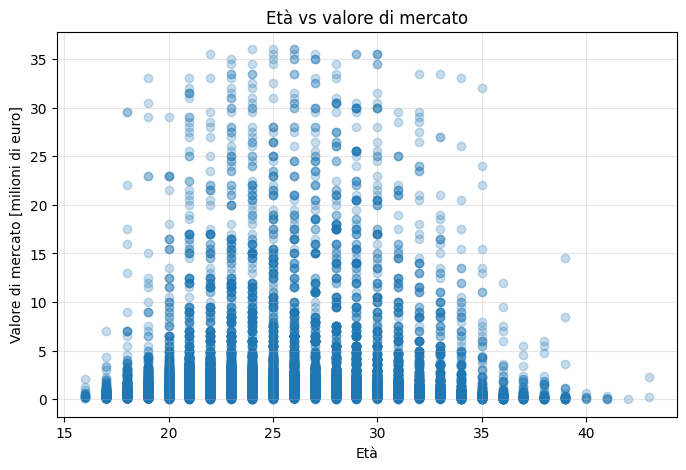

In [6]:
# Prepariamo la figura per il grafico. 
plt.figure(figsize=(8,5))

# Utiliziamo un grafico a dispersione (scatter plot) 
# alpha=0.25 rende i punti semitrasparenti, utile quando 
# ci sono molti punti sovrapposti per vedere meglio la densità dei dati.
plt.scatter(dataset["age"], dataset["value_mln_eur"], alpha=0.25)

# Aggiungiamo etichette agli assi, un titolo e una griglia 
# per migliorare la leggibilità del grafico. 
plt.xlabel("Età")
plt.ylabel("Valore di mercato [milioni di euro]")
plt.title("Età vs valore di mercato")
plt.grid(True, alpha=0.3)

# Mostriamo il grafico a schermo.
plt.show()

Il grafico mostra subito una cosa importante: l’età da sola non basta a spiegare il valore di mercato. Se ci fosse una relazione semplice e forte, i punti si disporrebbero lungo una linea o una curva ben definita. Invece vediamo una nuvola piuttosto dispersa.

Detto questo, una struttura comunque emerge. I giocatori molto giovani, intorno ai 17–19 anni, hanno quasi sempre valori bassi: questo è intuitivo, perché non hanno ancora dimostrato il loro livello. Spostandoci verso i 22–28 anni compare una maggiore variabilità: qui troviamo sia giocatori poco costosi sia quelli con i valori più alti. È come se questa fascia rappresentasse il "picco" della carriera, dove talento e maturità si combinano.

Dopo i 30 anni si nota invece una tendenza alla diminuzione: i valori alti diventano più rari e la maggior parte dei giocatori si concentra su valori più bassi. Questo suggerisce che l’età ha comunque un effetto: il valore cresce, raggiunge un massimo e poi decresce.

Un altro aspetto interessante è la grande dispersione verticale: a parità di età esistono giocatori con valori molto diversi. Questo indica che altre variabili (come il livello tecnico, il potenziale o il ruolo) hanno un peso determinante. In termini di modellazione, significa che stiamo osservando solo **una proiezione del problema su una dimensione**, mentre la realtà è molto più ricca.

In sintesi, il grafico suggerisce due idee chiave: l’età ha un effetto reale, ma parziale, e la relazione con il valore è complessa. Ed è proprio da qui che nasce la necessità di costruire un modello più sofisticato.

### Overall

Passiamo ora alla qualità tecnica complessiva, l’overall: è il punteggio (da 0 a 99) con cui FIFA sintetizza il livello attuale del giocatore. In questo caso è naturale aspettarsi una relazione più chiara: se davvero l’overall cattura bene la qualità, i punti dovrebbero disporsi in modo più ordinato, dando origine a una nuvola meno dispersa rispetto a quella osservata con l’età.

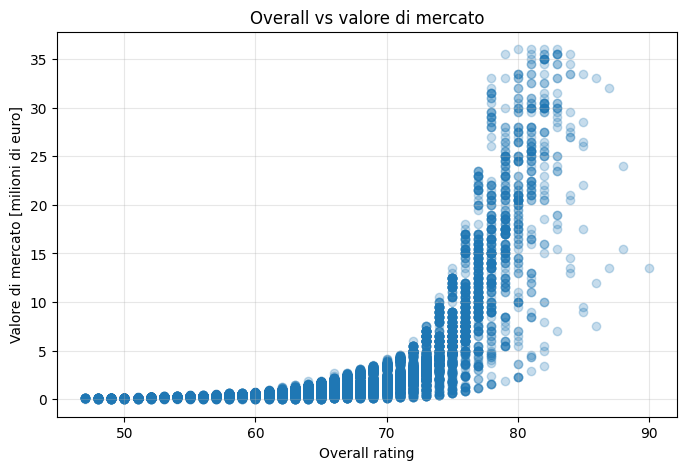

In [7]:
plt.figure(figsize=(8,5))
plt.scatter(dataset["overall"], dataset["value_mln_eur"], alpha=0.25)
plt.xlabel("Overall rating")
plt.ylabel("Valore di mercato [milioni di euro]")
plt.title("Overall vs valore di mercato")
plt.grid(True, alpha=0.3)
plt.show()

Qui il cambiamento è evidente: **la nuvola non è più disordinata** come nel caso dell’età, ma mostra una struttura molto più chiara. All’aumentare dell’overall, il valore di mercato cresce in modo deciso. I giocatori con overall basso (sotto 60–65) hanno quasi tutti valori molto ridotti, mentre a partire da circa 70–75 si osserva una crescita rapida, fino ai valori più alti per gli overall sopra 80. Questo suggerisce una **relazione forte tra le due variabili**.

La relazione, però, **non è perfettamente lineare**. La crescita sembra accelerare: piccoli aumenti di overall nella fascia alta corrispondono a grandi aumenti di valore. In altre parole, passare da 80 a 85 conta molto di più che passare da 60 a 65. Inoltre, rimane una certa dispersione verticale: a parità di overall esistono giocatori con valori diversi. Questo indica che anche qui intervengono altre variabili (ad esempio età, potenziale o ruolo), ma il segnale principale è chiaro.

In sintesi, rispetto all’età, l’overall è **una variabile molto più informativa**: da sola riesce già a spiegare una parte significativa del valore di mercato. Ed è proprio questo il tipo di variabile che vogliamo usare per costruire un modello predittivo efficace.

### Potential

Infine consideriamo il potential: il livello che un giocatore potrebbe raggiungere in futuro secondo le valutazioni dei talent scout di EA Sports. È una **misura più incerta e speculativa** rispetto all’overall, perché non descrive ciò che il giocatore è oggi, ma ciò che potrebbe diventare. Proprio per questo, però, è una variabile a cui il mercato presta grande attenzione: le società non acquistano solo prestazioni attuali, ma anche potenziale di crescita. Ci aspettiamo quindi una relazione meno pulita rispetto all’overall, ma comunque significativa, soprattutto per i giocatori più giovani.

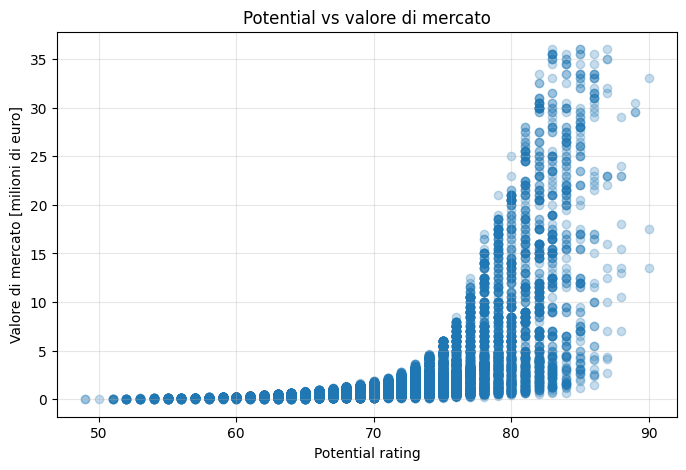

In [8]:
plt.figure(figsize=(8,5))
plt.scatter(dataset["potential"], dataset["value_mln_eur"], alpha=0.25)
plt.xlabel("Potential rating")
plt.ylabel("Valore di mercato [milioni di euro]")
plt.title("Potential vs valore di mercato")
plt.grid(True, alpha=0.3)
plt.show()

Il grafico mostra che anche il potential ha un legame chiaro con il valore di mercato: all’aumentare del potential, il valore cresce in modo evidente. I giocatori con potential basso hanno quasi sempre valori ridotti, mentre quelli con potential alto (sopra 80) possono raggiungere valori molto elevati. Questo conferma che il mercato tiene conto del talento futuro. Tuttavia, la nuvola è più sfocata rispetto a quella dell’overall. A parità di potential troviamo valori molto diversi: alcuni giocatori con grande potenziale valgono ancora poco, altri invece sono già molto costosi. Questo è coerente con l’interpretazione del potential: è una previsione, non una misura dello stato attuale. In altre parole, il potential introduce incertezza. Due giocatori con lo stesso potenziale possono trovarsi in fasi molto diverse della carriera: uno può essere già affermato, l’altro ancora da sviluppare. In sintesi, il potential è una variabile importante perché cattura il futuro, ma da sola non basta a determinare il valore. Il mercato sembra combinare ciò che il giocatore è oggi (overall) con ciò che potrebbe diventare (potential). Ed è proprio questa **combinazione** che un buon modello dovrà imparare a sfruttare.

## Misuriamo la forza delle relazioni

In generale, se al crescere di una feature tende a crescere anche il target, diciamo che c'è una **correlazione** positiva. Ad esempio, all'aumentare dell'overall o del potential, abbiamo visto che il valore di mercato tende a crescere. Rivediamo i grafici assieme:

Text(0.5, 1.0, 'Potential')

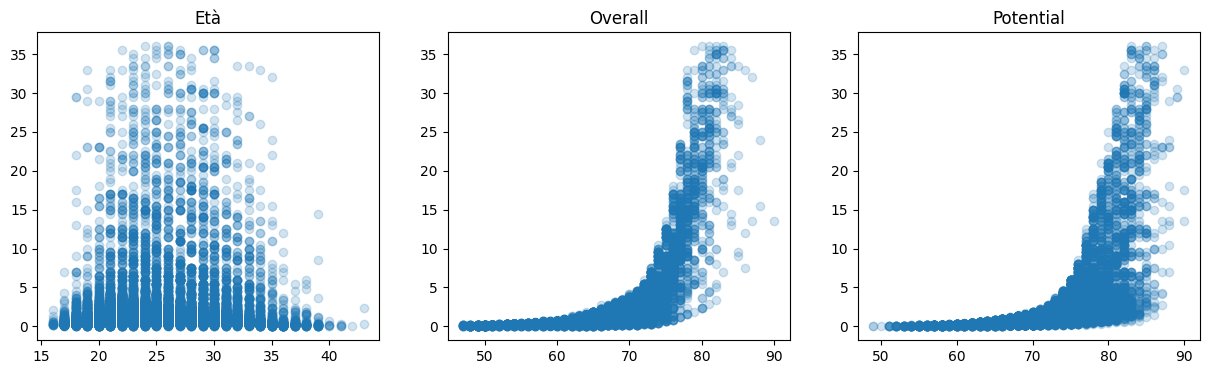

In [18]:
## Per confrontare meglio i tre grafici, li mettiamo affiancati in un'unica 
##f igura con 3 sottotrame (subplot)
plt.figure(figsize=(15,4))

# Il primo grafico mostra la relazione tra età e valore di mercato.
plt.subplot(1,3,1)
plt.scatter(dataset["age"], dataset["value_mln_eur"], alpha=0.2)
plt.title("Età")

# Il secondo grafico mostra la relazione tra overall e valore di mercato.
plt.subplot(1,3,2)
plt.scatter(dataset["overall"], dataset["value_mln_eur"], alpha=0.2)
plt.title("Overall")

# Il terzo grafico mostra la relazione tra potential e valore di mercato.
plt.subplot(1,3,3)
plt.scatter(dataset["potential"], dataset["value_mln_eur"], alpha=0.2)
plt.title("Potential")

L'overall è sicuramente più correlata al valore di mercato rispetto all'età, e probabilmente anche rispetto al potential, ma difficile dirlo a occhio. E inoltre, di quanto? Quale delle due variabili è più correlata al valore in un senso quantitativo?

### Correlazione

Per quantificare la forza di queste relazioni, possiamo usare una misura chiamata **coefficiente di correlazione**:

$\displaystyle r_{x,y} \;=\; \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2}\;\sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}$

Questa formula sembra complicata, ma in realtà sta facendo una cosa molto intuitiva: **misurare quanto due variabili si muovono insieme rispetto alle loro medie**. I termini

$\displaystyle (x_i - \bar{x}), \quad (y_i - \bar{y})$

misurano quanto ogni punto è sopra o sotto la media:

- se $x_i > \bar{x}$ allora il punto è “alto” rispetto alla media
-  e $x_i < \bar{x}$ allora il punto è “basso”

Stessa cosa per y. Il cuore della formula è il prodotto:

$\displaystyle (x_i - \bar{x})(y_i - \bar{y})$

Infatti, questo prodotto ci dice se i due punti si muovono insieme o in direzioni opposte:

- se entrambi sono sopra la media, allora il prodotto è positivo
- se entrambi sono sotto la media, allora il prodotto è positivo
- se uno è sopra e l’altro sotto, allora il prodotto è negativo

E quindi:

- se il prodotto è positivo, allora si muovono insieme
- se il prodotto è negativo, allora si muovono in direzioni opposte

Queste valutazione viene fatta per ogni punto, e i contributi di tutti i punti vengono sommati:

$\displaystyle \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$

Abbiamo però un problema ancora, se lasciassimo solo il numeratore, il valore dipenderebbe dalle unità di misura:

- euro
- milioni di euro
- metri
- anni

E' necessario quindi **normalizzare**, ovvero riportare tutto su una scala comune, eliminando le unità di misura e ottenendo un numero che va da -1 a 1. Per fare questo, dividiamo per la seguente quantità:

$\displaystyle \sqrt{\sum (x_i - \bar{x})^2} \quad \text{e} \quad \sqrt{\sum (y_i - \bar{y})^2}$

Per cui l'Interpretazione finale

$\displaystyle r_{x,y} =
\frac{\text{quanto si muovono insieme}}{\text{quanto variano}}$

E possiamo interpretare il risultato così:

- $r \approx 1$, allora le due variabili si muovono insieme in modo molto coerente
- $r \approx 0$, allora non c'è una relazione lineare
- $r \approx -1$, allora si muovono in direzioni opposte

Proviamo a calcolare questo coefficiente per le coppie (età, valore), (overall, valore) e (potential, valore) per capire quale delle tre variabili è più correlata al valore di mercato.

I tre grafici ci hanno dato un'intuizione, ma vogliamo un numero. Applichiamo la formula di Pearson al nostro dataset: per ogni variabile numerica calcoliamo la correlazione con il valore di mercato e ordiniamo dalla più *amica* del valore alla più *indifferente*.


In [12]:
# Individuiamo le colonne di interesse per il calcolo delle correlazioni
cols = ["age", "overall", "potential", "value_mln_eur"]

# calcoliamo le correlazioni usando il metodo .corr() di pandas, 
# che esegue il calcolo per noi.
corr = (dataset[cols].corr()["value_mln_eur"].sort_values(ascending=False))

print("Correlazione con il valore di mercato:")
print(corr)

Correlazione con il valore di mercato:
value_mln_eur    1.000000
overall          0.630757
potential        0.586482
age              0.056762
Name: value_mln_eur, dtype: float64


Il risultato quantifica in modo molto chiaro ciò che avevamo già intuito dai grafici. L’overall ha una correlazione piuttosto alta con il valore di mercato (0.63): non è perfetta, ma è decisamente significativa. Questo conferma che il livello attuale del giocatore è uno dei fattori principali nel determinare il prezzo. Il potential segue da vicino (0.59): è leggermente meno correlato dell’overall, ma comunque molto rilevante. Questo è coerente con l’idea che il mercato tenga conto anche del futuro, pur dando più peso al presente. L’età, invece, ha una correlazione quasi nulla (0.06), infatti come avevamo visto, il valore cresce fino a una certa età e poi decresce, quindi l’effetto "si annulla" nella correlazione.

### Importanza e Causalità

Conviene essere un po’ più precisi, perché qui si nascondono **due fraintendimenti molto comuni**.

Da un lato, **una correlazione bassa non significa affatto che una variabile non sia importante**. La correlazione che stiamo calcolando misura solo una relazione **lineare**: se il legame è più complesso (ad esempio cresce fino a un certo punto e poi decresce, come nel caso dell’età), il coefficiente può risultare vicino a zero anche quando la variabile ha un ruolo reale. In questi casi, la variabile contiene informazione, ma non nel modo semplice che la correlazione lineare riesce a catturare.

Dall’altro lato, **una correlazione alta non implica causalità**. Dire che due variabili sono fortemente correlate significa solo che, nei dati osservati, tendono a muoversi insieme. Non significa che una provochi l’altra: spesso entrambe dipendono da fattori più profondi o condividono una causa comune. Nel nostro esempio, l’overall è correlato al valore di mercato, ma non è l’overall "in sé" a causare il prezzo: entrambi riflettono la qualità reale del giocatore.

In sintesi, la correlazione è uno strumento molto utile per individuare relazioni nei dati e costruire modelli predittivi, ma va interpretata con cautela: non misura tutta la complessità delle relazioni e non fornisce spiegazioni causali.

> **Cosa dovremmo aver capito** — Abbiamo visto che il valore di mercato di un calciatore non dipende da una singola caratteristica, ma emerge da una combinazione di fattori: alcune variabili, come l’overall, mostrano una relazione chiara e lineare, altre, come l’età, hanno effetti più complessi; e che per capire queste relazioni possiamo partire dall’intuizione visiva e poi quantificarla con strumenti matematici come la correlazione.

> **Cosa faremo adesso** — Nel prossimo notebook inizieremo a costruire il nostro primo scout automatico: un modello semplice che prova a stimare il valore di un giocatore guardando solo al suo overall.